In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Literal
from collections import defaultdict

In [2]:
# Settings
data_dir: str = (
    "../results"
)
env: Literal[
    "Pendulum-v1", "BipedalWalker-v3", "LunarLanderContinuous-v3", "all"
] = "all"
ema_alpha: float = 0.01

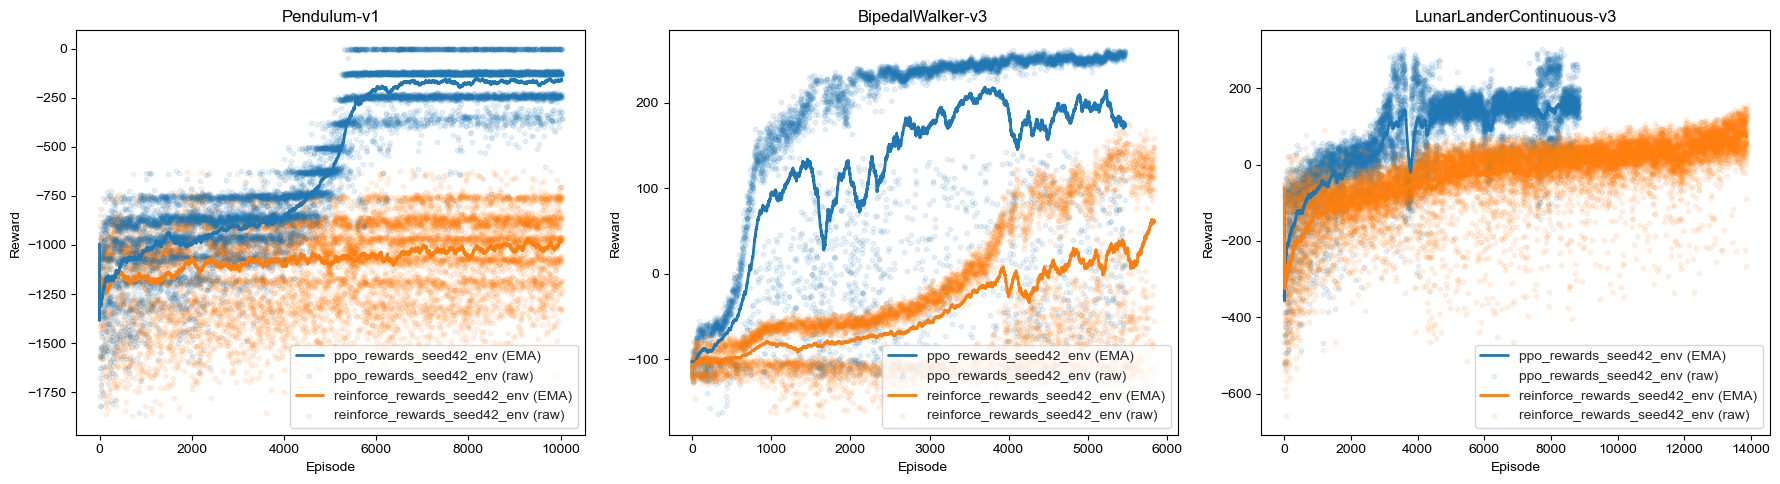

In [3]:
# Environment list
all_envs = ["Pendulum-v1", "BipedalWalker-v3", "LunarLanderContinuous-v3"]
envs_to_plot = all_envs if env == "all" else [env]

# Gather all unique method names
csv_files = list(Path(data_dir).rglob("*.csv"))
method_names = set()
for file in csv_files:
    for e in all_envs:
        if e in file.stem:
            method = file.stem.replace(e, "").strip("_-")
            method_names.add(method)

# Assign a consistent color to each method
palette = sns.color_palette("tab10", n_colors=len(method_names))
method_to_color = dict(zip(sorted(method_names), palette))

# Setup subplots
fig, axes = plt.subplots(
    1, len(envs_to_plot), figsize=(6 * len(envs_to_plot), 5), squeeze=False
)
axes = axes[0]
sns.set_theme(style="whitegrid")

for ax, env_name in zip(axes, envs_to_plot):
    files = list(Path(data_dir).rglob(f"*{env_name}.csv"))

    for file in files:
        method_name = file.stem.replace(env_name, "").strip("_-")
        df = pd.read_csv(file).sort_values("Episode")
        df["ema"] = df["Reward"].ewm(alpha=ema_alpha).mean()

        color = method_to_color.get(method_name, "gray")

        # Plot raw rewards (light color)
        ax.scatter(
            df["Episode"],
            df["Reward"],
            alpha=0.1,
            s=10,
            label=f"{method_name} (raw)",
            color=color,
        )
        # Plot EMA (same color, bold)
        ax.plot(
            df["Episode"],
            df["ema"],
            linewidth=2,
            label=f"{method_name} (EMA)",
            color=color,
        )

    ax.set_title(env_name)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")

    # Sort legend so PPO comes first
    handles, labels = ax.get_legend_handles_labels()
    sorted_items = sorted(
        zip(labels, handles),
        key=lambda x: (0 if "ppo" in x[0].lower() else 1, x[0].lower()),
    )
    sorted_labels, sorted_handles = zip(*sorted_items)
    ax.legend(sorted_handles, sorted_labels, loc="lower right", fontsize=10)


plt.tight_layout()
plt.show()